# IEEE-CIS Fraud Detection Project

## Overview
This notebook walks through a complete fraud detection pipeline on 590,000 real banking transactions.
We cover data loading, EDA, feature engineering, model building, SHAP explainability, and a real-time scoring simulation.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8')

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 2: Load & Merge Data
We have two files:
- `train_transaction.csv` - core transaction details
- `train_identity.csv` - device and identity information per transaction

We merge them on `TransactionID` using a left join since not every transaction has identity data.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

transaction = pd.read_csv('/content/drive/MyDrive/Projects/fraud_detection/train_transaction.csv')
identity = pd.read_csv('/content/drive/MyDrive/Projects/fraud_detection/train_identity.csv')

df = transaction.merge(identity, on='TransactionID', how='left')

print("Transaction shape:", transaction.shape)
print("Identity shape:", identity.shape)
print("Merged shape:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Transaction shape: (590540, 394)
Identity shape: (144233, 41)
Merged shape: (590540, 434)


## Step 3: First Look at the Data
Let's check the first few rows, data types, and basic statistics.

In [3]:
print("First 5 rows:")
df.head()

First 5 rows:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [4]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


In [5]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,238269.000000,37627.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,589271.000000,309743.000000,327662.000000,421618.000000,280699.000000,73187.000000,38917.000000,74926.000000,74926.000000,514518.000000,311253.000000,64717.000000,61952.000000,62187.000000,501427.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,...,589271.000000,589271.000000,589271.000000,590528.000000,590528.000000,590528.000000,590528.000000,590528.000000,590528.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000,144233.000000,140872.000000,66324.000000,66324.000000,136865.000000,136865.000000,5155.000000,5155.000000,74926.000000,74926.000000,140978.000000,127320.000000,80044.000000,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,118.502180,231.855423,14.092458,15.269734,0.005644,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215,94.347568,169.563231,28.343348,140.002441,42.335965,69.805717,41.638950,146.058108,0.561057,123.982137,146.621465,54.037533,17.901295,57.724444,163.744579,0.999945,1.045204,1.078075,0.846456,0.876991,1.045686,1.072870,1.027704,1.041529,...,21.351473,43.319174,26.806977,109.818544,247.606741,162.153398,18.372476,42.073133,28.326584,6.220289,13.103775,9.184612,0.058494,0.851040,0.296633,0.336790,1.312844,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882,-10.170502,174716.584708,0.060189,-0.058938,1.615585,-6.698710,13.285354,-38.600388,0.091023,-0.301124,99.745325,48.053071,-344.507146,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,371.872026,529.053494,133.569018,154.668899,0.150536,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262,157.660387,177.315865,62.384721,191.096774,89.000144,143.669253,99.743264,231.663840,0.316880,182.615225,186.042622,124.274558,67.614425,136.312450,202.726660,0.007390,0.240133,0.320890,0.440053,0.475902,0.239385,0.304779,0.186069,0.226339,...,95.902970,173.619028,116.853222,2270.033202,3980.042828,2793.343636,332.304848,473.499307,382.053171,56.022561,106.739813,73.627893,0.304415,3.950295,1.364356,1.580144,8.769083,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722,14.347949,159651.816856,0.598231,0.701015,5.249856,16.491104,11.384207,26.084899,0.983842,2.789446,1.127602,11.774858,93.695502,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000

## Step 4: Check Class Imbalance
This is the core challenge of fraud detection.
Fraudulent transactions are a tiny fraction, standard ML models will simply ignore them.
We need to understand exactly how imbalanced our data is.

Fraud Count:
 isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud Percentage:
 isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64


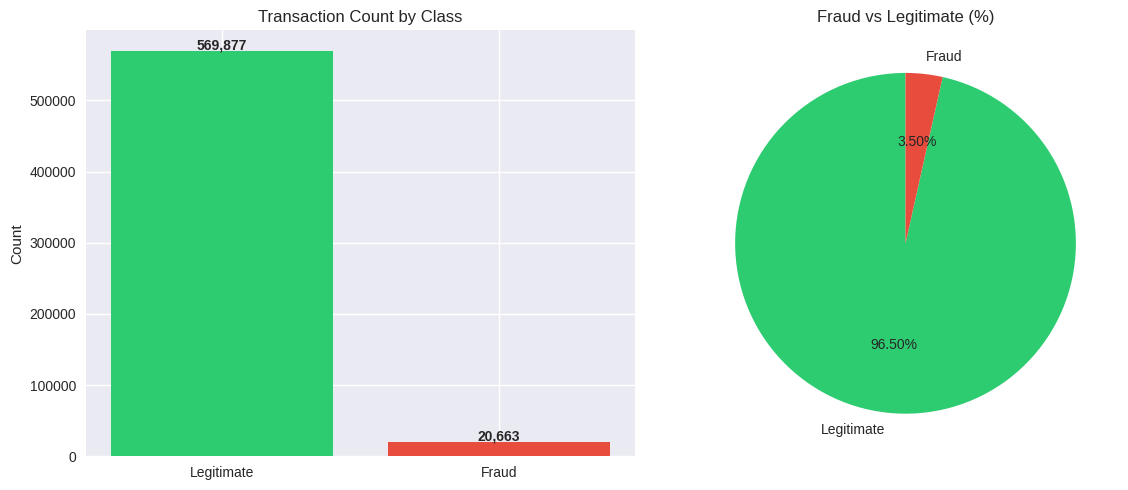

In [6]:
fraud_count = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print("Fraud Count:\n", fraud_count)
print("\nFraud Percentage:\n", fraud_pct.round(2))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
axes[0].bar(['Legitimate', 'Fraud'], fraud_count.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Percentage plot
axes[1].pie(fraud_pct.values, labels=['Legitimate', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Fraud vs Legitimate (%)')

plt.tight_layout()
plt.show()

## Step 5: Missing Values Analysis
Many columns in this dataset have significant missing data.
Understanding which features are missing and by how much helps us decide how to handle them later.

Total columns with missing values: 414
       Missing Count  Missing %
id_24         585793      99.20
id_21         585381      99.13
id_26         585377      99.13
id_07         585385      99.13
id_08         585385      99.13
id_25         585408      99.13
id_22         585371      99.12
id_27         585371      99.12
id_23         585371      99.12
dist2         552913      93.63
D7            551623      93.41
id_18         545427      92.36
D13           528588      89.51
D14           528353      89.47
D12           525823      89.04
id_04         524216      88.77
id_03         524216      88.77
D6            517353      87.61
id_33         517251      87.59
D8            515614      87.31


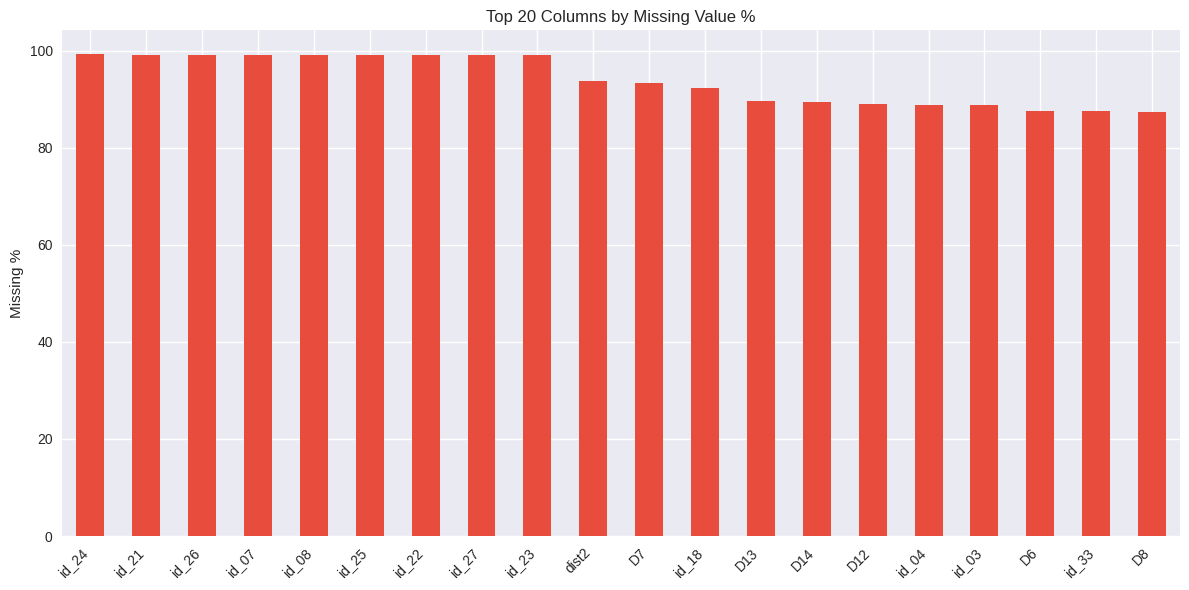

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(f"Total columns with missing values: {len(missing_df)}")
print(missing_df.head(20))

# Plot top 20 missing
plt.figure(figsize=(12, 6))
missing_df.head(20)['Missing %'].plot(kind='bar', color='#e74c3c')
plt.title('Top 20 Columns by Missing Value %')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 6: Transaction Amount Analysis
Let's look at how transaction amounts differ between fraud and legitimate transactions.
Fraudsters often target specific amount ranges.

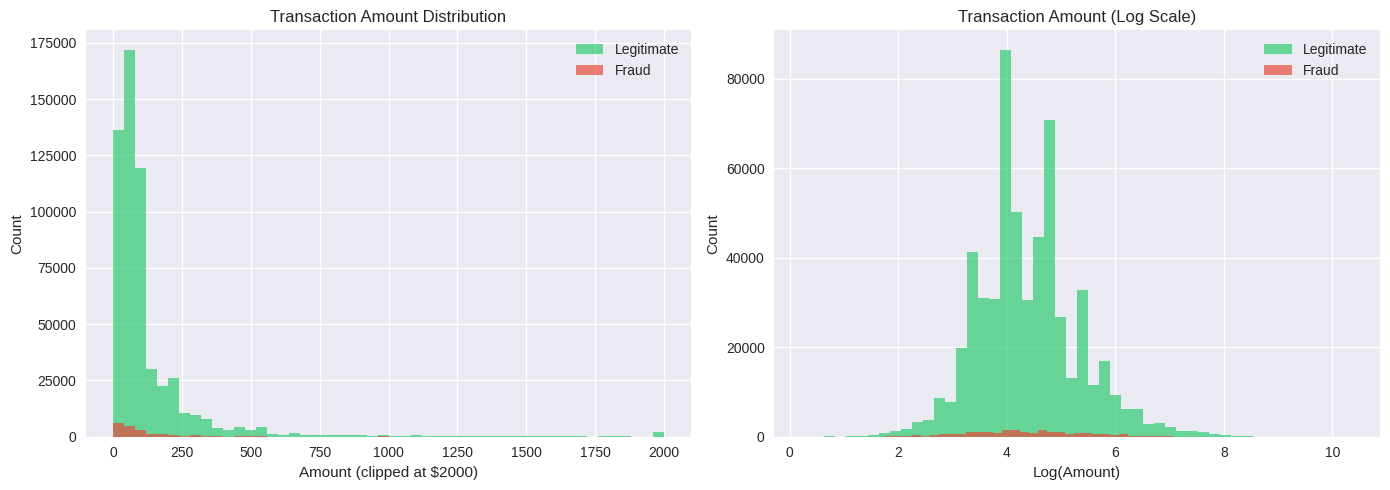

Legitimate transactions - Amount stats:
count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

Fraud transactions - Amount stats:
count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of transaction amounts
axes[0].hist(df[df['isFraud'] == 0]['TransactionAmt'].clip(upper=2000),
             bins=50, alpha=0.7, color='#2ecc71', label='Legitimate')
axes[0].hist(df[df['isFraud'] == 1]['TransactionAmt'].clip(upper=2000),
             bins=50, alpha=0.7, color='#e74c3c', label='Fraud')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (clipped at $2000)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Log scale version for better visibility
axes[1].hist(np.log1p(df[df['isFraud'] == 0]['TransactionAmt']),
             bins=50, alpha=0.7, color='#2ecc71', label='Legitimate')
axes[1].hist(np.log1p(df[df['isFraud'] == 1]['TransactionAmt']),
             bins=50, alpha=0.7, color='#e74c3c', label='Fraud')
axes[1].set_title('Transaction Amount (Log Scale)')
axes[1].set_xlabel('Log(Amount)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Legitimate transactions - Amount stats:")
print(df[df['isFraud'] == 0]['TransactionAmt'].describe())
print("\nFraud transactions - Amount stats:")
print(df[df['isFraud'] == 1]['TransactionAmt'].describe())

## Step 7: Feature Engineering
Raw features alone are not enough. We create new features that help the model detect fraud patterns better.
We will engineer:
- Transaction velocity (how fast someone is spending)
- Time-based patterns (hour, day of week)
- Device fingerprinting proxies
- Amount-based features

### 7.1 Time-Based Features
`TransactionDT` is a timedelta in seconds from a reference point - not a real timestamp.
We extract hour and day patterns from it since fraud often happens at specific times.

In [9]:
# Convert TransactionDT to useful time features
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['week'] = (df['TransactionDT'] // (3600 * 24 * 7)) % 52

print("Time features created: hour, day_of_week, week")
print(df[['TransactionDT', 'hour', 'day_of_week', 'week']].head())

Time features created: hour, day_of_week, week
   TransactionDT  hour  day_of_week  week
0          86400     0            1     0
1          86401     0            1     0
2          86469     0            1     0
3          86499     0            1     0
4          86506     0            1     0


### 7.2 Transaction Amount Features
We create log-transformed and rounded amount features.
Fraudsters often use specific round amounts or very precise amounts to test cards.

In [10]:
# Log transform of amount (reduces skewness)
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])

# Decimal part of amount (fraudsters often use .00 or .99)
df['TransactionAmt_decimal'] = df['TransactionAmt'] - np.floor(df['TransactionAmt'])

# Is it a round number?
df['is_round_amount'] = (df['TransactionAmt_decimal'] == 0).astype(int)

print("Amount features created")
print(df[['TransactionAmt', 'TransactionAmt_log', 'TransactionAmt_decimal', 'is_round_amount']].head(10))

Amount features created
   TransactionAmt  TransactionAmt_log  TransactionAmt_decimal  is_round_amount
0            68.5            4.241327                     0.5                0
1            29.0            3.401197                     0.0                1
2            59.0            4.094345                     0.0                1
3            50.0            3.931826                     0.0                1
4            50.0            3.931826                     0.0                1
5            49.0            3.912023                     0.0                1
6           159.0            5.075174                     0.0                1
7           422.5            6.048554                     0.5                0
8            15.0            2.772589                     0.0                1
9           117.0            4.770685                     0.0                1


### 7.3 Transaction Velocity Features
How many transactions are happening per card and per email domain?
High velocity is a strong fraud signal.

In [11]:
# Count of transactions per card
df['card1_count'] = df.groupby('card1')['card1'].transform('count')
df['card2_count'] = df.groupby('card2')['card2'].transform('count')

# Count of transactions per email domain
df['P_emaildomain_count'] = df.groupby('P_emaildomain')['P_emaildomain'].transform('count')
df['R_emaildomain_count'] = df.groupby('R_emaildomain')['R_emaildomain'].transform('count')

# Transaction amount mean per card (deviation from normal spending)
df['card1_amt_mean'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['card1_amt_std'] = df.groupby('card1')['TransactionAmt'].transform('std')

# How much does this transaction deviate from the card's average?
df['amt_deviation'] = (df['TransactionAmt'] - df['card1_amt_mean']) / (df['card1_amt_std'] + 1)

print("Velocity features created")
print(df[['card1', 'card1_count', 'card1_amt_mean', 'amt_deviation']].head(10))

Velocity features created
   card1  card1_count  card1_amt_mean  amt_deviation
0  13926           43      351.931163      -0.761623
1   2755          683      234.292753      -0.444976
2   4663         1108       97.015542      -0.375912
3  18132         4209      123.416340      -0.378987
4   4497           18       96.972222      -0.815073
5   5937            7      134.071429      -0.844320
6  12308          207      101.880097       0.321395
7  12695         7091      141.144645       1.300868
8   2803         6141      142.683409      -0.485520
9  17399         1916      122.020491      -0.025082


### 7.4 Device Fingerprinting Proxy Features
The identity table has device info. We create proxy features to capture device-level fraud patterns.

In [12]:
# Device type and info counts
if 'DeviceType' in df.columns:
    df['DeviceType_count'] = df.groupby('DeviceType')['DeviceType'].transform('count')
    print("DeviceType feature created")

if 'DeviceInfo' in df.columns:
    df['DeviceInfo_count'] = df.groupby('DeviceInfo')['DeviceInfo'].transform('count')
    print("DeviceInfo feature created")

# How many unique cards per email domain (proxy for synthetic identity fraud)
email_card_count = df.groupby('P_emaildomain')['card1'].nunique().reset_index()
email_card_count.columns = ['P_emaildomain', 'email_unique_cards']
df = df.merge(email_card_count, on='P_emaildomain', how='left')

print("Device fingerprinting proxy features created")

DeviceType feature created
DeviceInfo feature created
Device fingerprinting proxy features created


### 7.5 Visualise New Features vs Fraud
Let's confirm our new features actually separate fraud from legitimate transactions.

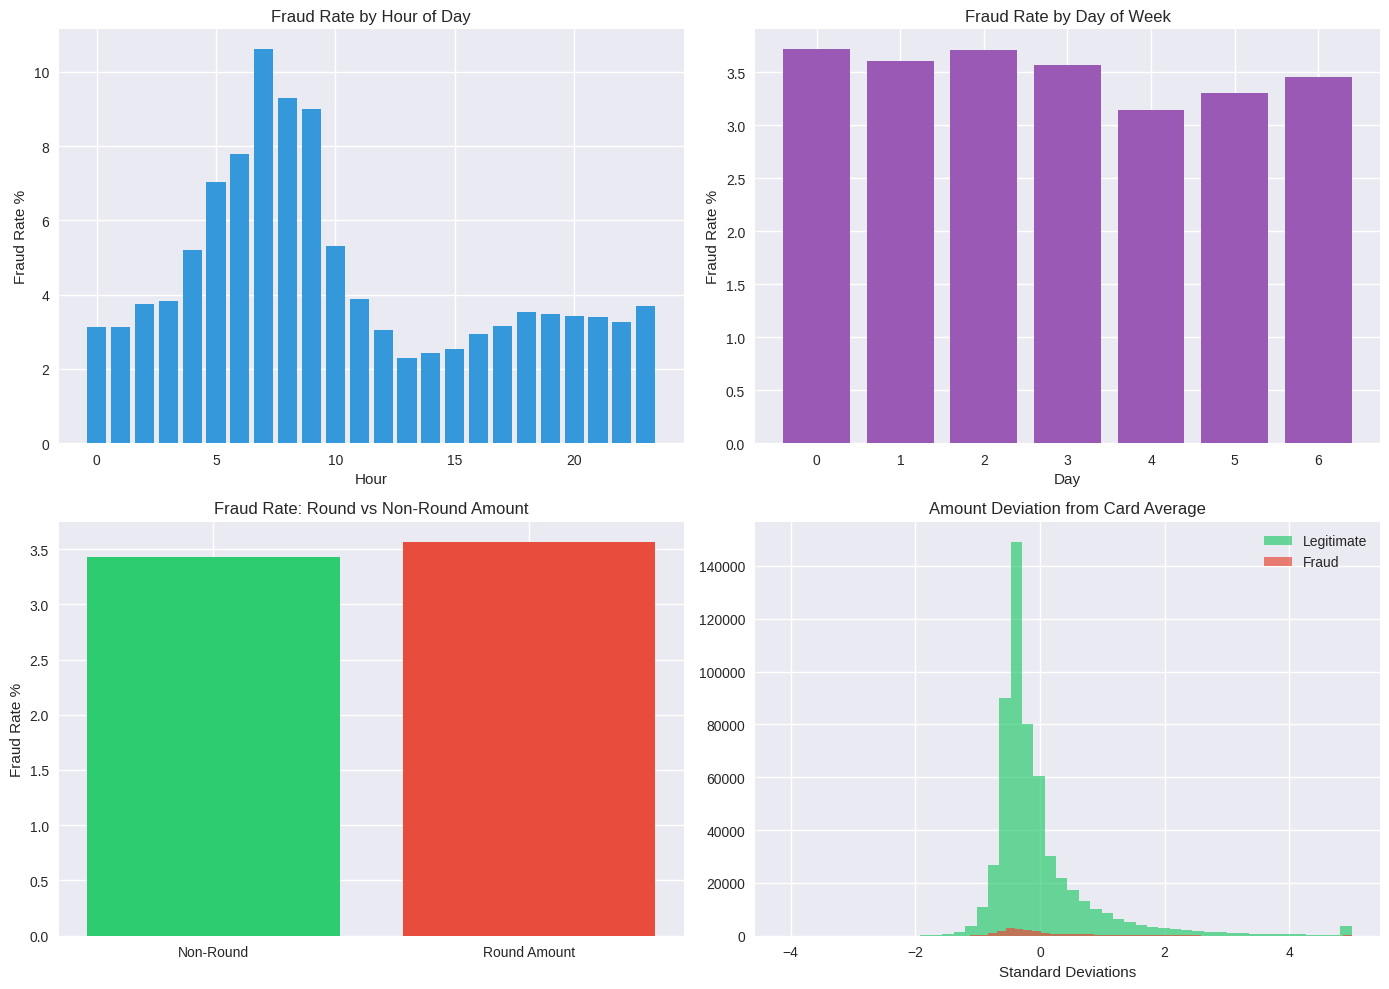

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hour vs Fraud
hour_fraud = df.groupby('hour')['isFraud'].mean() * 100
axes[0, 0].bar(hour_fraud.index, hour_fraud.values, color='#3498db')
axes[0, 0].set_title('Fraud Rate by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Fraud Rate %')

# Day of week vs Fraud
day_fraud = df.groupby('day_of_week')['isFraud'].mean() * 100
axes[0, 1].bar(day_fraud.index, day_fraud.values, color='#9b59b6')
axes[0, 1].set_title('Fraud Rate by Day of Week')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Fraud Rate %')

# Round amount vs Fraud
round_fraud = df.groupby('is_round_amount')['isFraud'].mean() * 100
axes[1, 0].bar(['Non-Round', 'Round Amount'], round_fraud.values, color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Fraud Rate: Round vs Non-Round Amount')
axes[1, 0].set_ylabel('Fraud Rate %')

# Amount deviation vs Fraud
axes[1, 1].hist(df[df['isFraud'] == 0]['amt_deviation'].clip(-5, 5),
                bins=50, alpha=0.7, color='#2ecc71', label='Legitimate')
axes[1, 1].hist(df[df['isFraud'] == 1]['amt_deviation'].clip(-5, 5),
                bins=50, alpha=0.7, color='#e74c3c', label='Fraud')
axes[1, 1].set_title('Amount Deviation from Card Average')
axes[1, 1].set_xlabel('Standard Deviations')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 7.6 Summary of Engineered Features

In [14]:
new_features = [
    'hour', 'day_of_week', 'week',
    'TransactionAmt_log', 'TransactionAmt_decimal', 'is_round_amount',
    'card1_count', 'card2_count',
    'P_emaildomain_count', 'R_emaildomain_count',
    'card1_amt_mean', 'card1_amt_std', 'amt_deviation',
    'email_unique_cards'
]

print(f"Total new features engineered: {len(new_features)}")
print("\nNew features list:")
for f in new_features:
    print(f"  - {f}")

print(f"\nTotal columns in dataset now: {df.shape[1]}")

Total new features engineered: 14

New features list:
  - hour
  - day_of_week
  - week
  - TransactionAmt_log
  - TransactionAmt_decimal
  - is_round_amount
  - card1_count
  - card2_count
  - P_emaildomain_count
  - R_emaildomain_count
  - card1_amt_mean
  - card1_amt_std
  - amt_deviation
  - email_unique_cards

Total columns in dataset now: 450


## Step 8: Data Preprocessing & Handling Class Imbalance
Before we can train any model we need to:
1. Drop or fill missing values
2. Encode categorical columns into numbers
3. Select our final feature set
4. Split into train and test sets
5. Apply SMOTE to balance the fraud vs legitimate ratio

### 8.1 Drop High Missing Value Columns
Columns with more than 50% missing values add noise rather than signal.
We drop them and fill remaining missing values with the median or mode.

In [15]:
# Drop columns with more than 50% missing
threshold = 0.5
missing_pct = df.isnull().sum() / len(df)
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()

print(f"Columns dropped due to > 50% missing: {len(cols_to_drop)}")
df = df.drop(columns=cols_to_drop)
print(f"Remaining columns: {df.shape[1]}")

Columns dropped due to > 50% missing: 217
Remaining columns: 233


### 8.2 Encode Categorical Columns
Machine learning models need numbers - not text.
We label encode all categorical (object type) columns.

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {len(categorical_cols)}")
print(categorical_cols)

for col in categorical_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

print("\n All categorical columns encoded successfully")

Categorical columns to encode: 9
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6']

 All categorical columns encoded successfully


### 8.3 Fill Remaining Missing Values
For numeric columns still having missing values we fill with the median.
Median is preferred over mean because it is robust to outliers - common in fraud data.

In [17]:
# Fill remaining numeric missing values with median
missing_before = df.isnull().sum().sum()
df = df.fillna(df.median(numeric_only=True))
missing_after = df.isnull().sum().sum()

print(f"Missing values before fill: {missing_before}")
print(f"Missing values after fill:  {missing_after}")
print("All missing values handled")

Missing values before fill: 12879705
Missing values after fill:  0
All missing values handled


### 8.4 Define Feature Set and Target
We separate the dataset into:
- `X` - all input features the model learns from
- `y` - the target column (isFraud) we are trying to predict
We also drop `TransactionID` as it is just an identifier with no predictive value.

In [18]:
# Drop non-useful columns
drop_cols = ['TransactionID', 'isFraud']
X = df.drop(columns=drop_cols)
y = df['isFraud']

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFraud cases: {y.sum():,}")
print(f"Legitimate cases: {(y == 0).sum():,}")
print(f"Fraud rate: {y.mean() * 100:.2f}%")

Feature matrix shape: (590540, 231)
Target shape: (590540,)

Fraud cases: 20,663
Legitimate cases: 569,877
Fraud rate: 3.50%


### 8.5 Train Test Split
We split 80% for training and 20% for testing.
`stratify=y` ensures both splits have the same fraud ratio - very important with imbalanced data.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size:   {X_train.shape}")
print(f"Test set size:       {X_test.shape}")
print(f"\nTraining fraud rate: {y_train.mean() * 100:.2f}%")
print(f"Test fraud rate:     {y_test.mean() * 100:.2f}%")
print("Train test split done")

Training set size:   (472432, 231)
Test set size:       (118108, 231)

Training fraud rate: 3.50%
Test fraud rate:     3.50%
Train test split done


### 8.6 Apply SMOTE - Synthetic Minority Oversampling
SMOTE creates **synthetic** fraud samples by interpolating between existing fraud cases.
This gives the model enough fraud examples to actually learn from.
We only apply SMOTE to the **training set** - never the test set.
Applying it to test data would give fake evaluation results.

In [20]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE - this may take a few minutes...")
print(f"Before SMOTE - Fraud: {y_train.sum():,} | Legitimate: {(y_train==0).sum():,}")

smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  - Fraud: {y_train_sm.sum():,} | Legitimate: {(y_train_sm==0).sum():,}")
print(f"\nNew training set size: {X_train_sm.shape}")
print("SMOTE applied successfully")

Applying SMOTE - this may take a few minutes...
Before SMOTE - Fraud: 16,530 | Legitimate: 455,902
After SMOTE  - Fraud: 136,770 | Legitimate: 455,902

New training set size: (592672, 231)
SMOTE applied successfully


### 8.7 Visualise Class Balance Before and After SMOTE

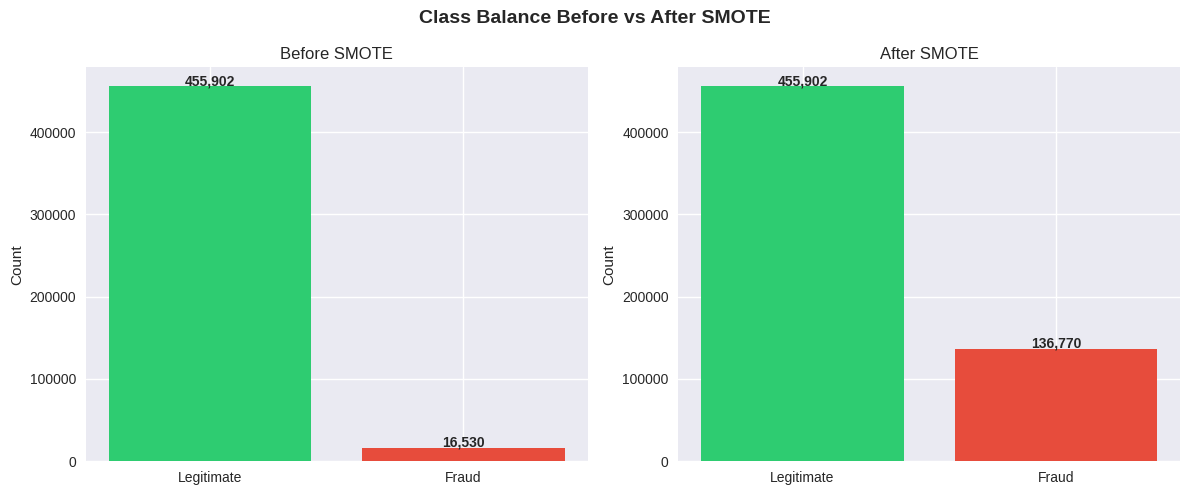

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
before = y_train.value_counts()
axes[0].bar(['Legitimate', 'Fraud'], before.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# After SMOTE
after = pd.Series(y_train_sm).value_counts()
axes[1].bar(['Legitimate', 'Fraud'], after.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Balance Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9: Model Building
We build and compare three models:
1. **XGBoost** - gradient boosting, industry standard for fraud detection
2. **Random Forest** - ensemble of decision trees, robust and interpretable
3. **Isolation Forest** - unsupervised anomaly detection, no labels needed

Each model is evaluated on:
- Precision - of all flagged fraud, how many were actually fraud?
- Recall - of all actual fraud, how many did we catch?
- F1 Score - balance between precision and recall
- AUC-ROC - overall model discrimination ability

### 9.1 Define Evaluation Function
We create a reusable function so we can evaluate all models consistently.

In [22]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, precision_score, recall_score)

def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    print(f"  {model_name} - Evaluation Report")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Fraud']))

    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)

    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
        print(f"AUC-ROC   : {auc:.4f}")
    else:
        auc = None

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'precision': precision,
            'recall': recall, 'f1': f1, 'auc': auc}

print("Evaluation function defined")

Evaluation function defined


### 9.2 Model 1 - XGBoost
XGBoost is the most widely used model in fraud detection competitions and production systems.
It builds trees sequentially where each tree corrects the errors of the previous one.
We use `scale_pos_weight` as an additional technique to handle class imbalance on top of SMOTE.

Training XGBoost - please wait...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:22:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  XGBoost - Evaluation Report

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99    113975
       Fraud       0.64      0.55      0.59      4133

    accuracy                           0.97    118108
   macro avg       0.81      0.77      0.79    118108
weighted avg       0.97      0.97      0.97    118108

Precision : 0.6359
Recall    : 0.5519
F1 Score  : 0.5909
AUC-ROC   : 0.9226


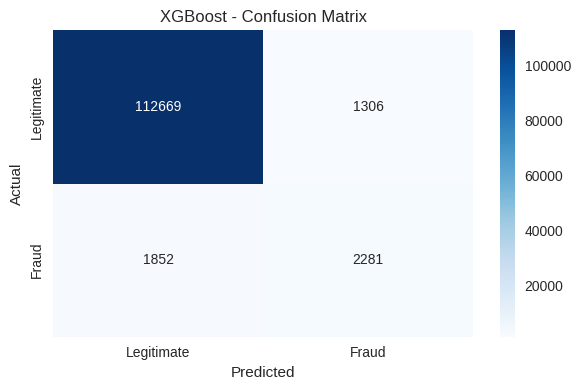

XGBoost training complete


In [23]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for additional imbalance handling
scale = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost - please wait...")
xgb_model.fit(X_train_sm, y_train_sm)

xgb_pred  = xgb_model.predict(X_test)
xgb_prob  = xgb_model.predict_proba(X_test)[:, 1]

xgb_results = evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob)
print("XGBoost training complete")

### 9.3 Model 2 - Random Forest
Random Forest builds many independent decision trees and takes a majority vote.
It is more robust to overfitting than a single decision tree.
`class_weight='balanced'` tells it to pay more attention to the minority fraud class.

Training Random Forest - please wait...
  Random Forest - Evaluation Report

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.96      0.97    113975
       Fraud       0.35      0.56      0.43      4133

    accuracy                           0.95    118108
   macro avg       0.66      0.76      0.70    118108
weighted avg       0.96      0.95      0.95    118108

Precision : 0.3460
Recall    : 0.5609
F1 Score  : 0.4280
AUC-ROC   : 0.8767


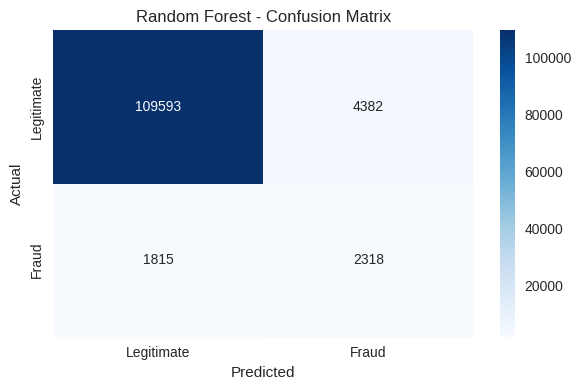

Random Forest training complete


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest - please wait...")
rf_model.fit(X_train_sm, y_train_sm)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_results = evaluate_model('Random Forest', y_test, rf_pred, rf_prob)
print("Random Forest training complete")

### 9.4 Model 3 - Isolation Forest
Isolation Forest is an **unsupervised** anomaly detection algorithm.
It does not use labels at all - it finds fraud by isolating outliers in the data.
This makes it useful in real-world scenarios where labeled fraud data is scarce.

Training Isolation Forest - please wait...
  Isolation Forest - Evaluation Report

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.98      0.98    113975
       Fraud       0.17      0.09      0.12      4133

    accuracy                           0.95    118108
   macro avg       0.57      0.54      0.55    118108
weighted avg       0.94      0.95      0.95    118108

Precision : 0.1650
Recall    : 0.0893
F1 Score  : 0.1159


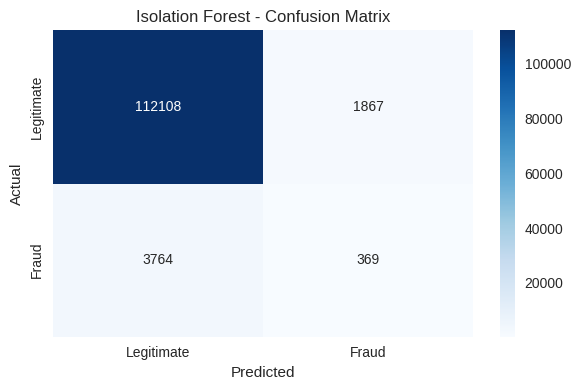

Isolation Forest training complete


In [25]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.035,
    random_state=42,
    n_jobs=-1
)

print("Training Isolation Forest - please wait...")
iso_model.fit(X_train_sm)

# Isolation Forest returns -1 for anomaly, 1 for normal
# We convert to 1 for fraud, 0 for legitimate
iso_raw  = iso_model.predict(X_test)
iso_pred = (iso_raw == -1).astype(int)

iso_results = evaluate_model('Isolation Forest', y_test, iso_pred)
print("Isolation Forest training complete")

### 9.5 ROC Curve Comparison
The ROC curve shows the tradeoff between catching fraud (recall) and raising false alarms.
A model hugging the top-left corner is better.
AUC closer to 1.0 means better overall performance.

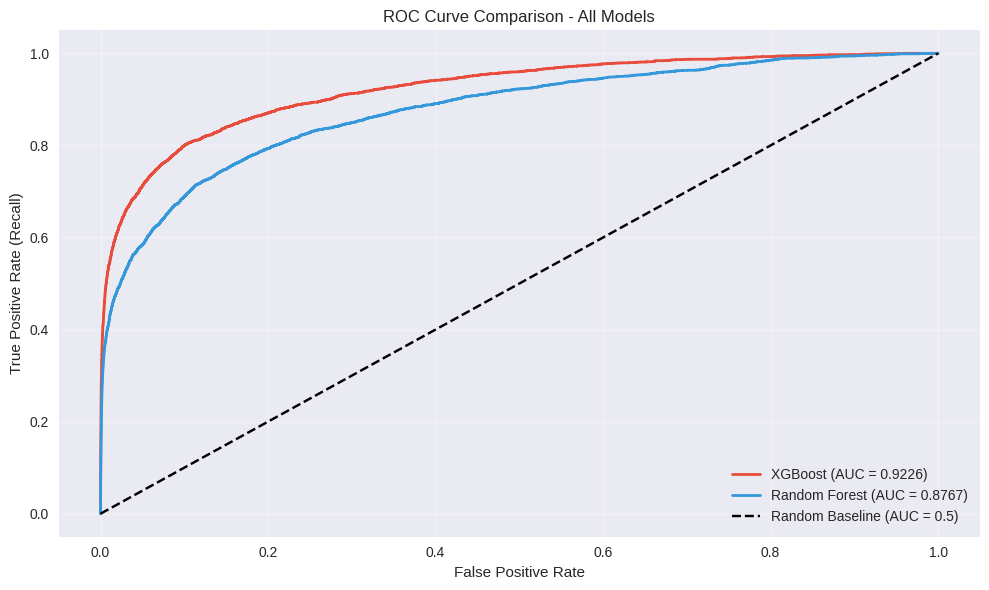

In [26]:
plt.figure(figsize=(10, 6))

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr_xgb, tpr_xgb,
         label=f"XGBoost (AUC = {xgb_results['auc']:.4f})",
         color='#e74c3c', linewidth=2)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {rf_results['auc']:.4f})",
         color='#3498db', linewidth=2)

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison - All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.6 Model Comparison Summary Table


Model Comparison Summary:
                  precision  recall      f1     auc
model                                              
XGBoost              0.6359  0.5519  0.5909  0.9226
Random Forest        0.3460  0.5609  0.4280  0.8767
Isolation Forest     0.1650  0.0893  0.1159     NaN


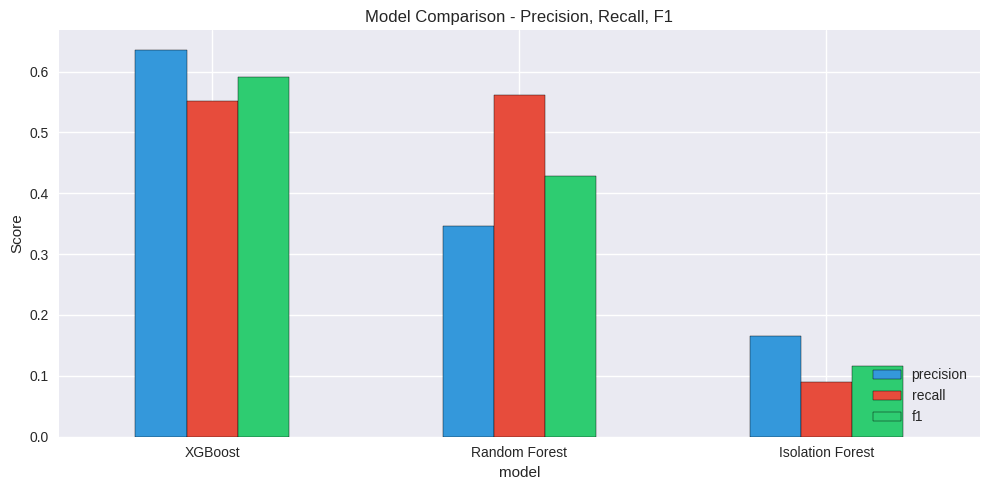


Best model by F1 Score: XGBoost
Best model by AUC-ROC: XGBoost


In [27]:
results_df = pd.DataFrame([xgb_results, rf_results, iso_results])
results_df = results_df.set_index('model')
results_df = results_df.round(4)

print("\nModel Comparison Summary:")
print(results_df.to_string())

# Plot comparison
results_df[['precision', 'recall', 'f1']].plot(
    kind='bar', figsize=(10, 5),
    color=['#3498db', '#e74c3c', '#2ecc71'],
    edgecolor='black'
)
plt.title('Model Comparison - Precision, Recall, F1')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nBest model by F1 Score:", results_df['f1'].idxmax())
print("Best model by AUC-ROC:", results_df['auc'].idxmax())

## Step 10: SHAP Explainability
A fraud flag is useless if you cannot explain **why** a transaction was flagged.
Regulators, investigators, and customers all need clear reasons.

SHAP (SHapley Additive exPlanations) tells us:
- Which features pushed the model toward flagging fraud
- Which features pushed against it
- A plain-English reason for every single flagged transaction

We use SHAP on our best model - XGBoost.

### 10.1 Install and Import SHAP

In [28]:
!pip install shap -q

import shap

# Initialize SHAP explainer with XGBoost model
explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer initialized")

SHAP explainer initialized


### 10.2 Compute SHAP Values
We compute SHAP values on a sample of the test set.
Using the full test set would take too long - 2000 samples is enough for reliable explanations.

In [29]:
# Sample 2000 rows from test set for SHAP analysis
sample_size = 2000
X_test_sample = X_test.iloc[:sample_size]
y_test_sample = y_test.iloc[:sample_size]

print("Computing SHAP values - please wait...")
shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values computed for {sample_size} transactions")
print(f"SHAP values shape: {shap_values.shape}")

Computing SHAP values - please wait...
SHAP values computed for 2000 transactions
SHAP values shape: (2000, 231)


### 10.3 Global Feature Importance - Summary Plot
This plot shows which features matter most **across all transactions**.
Features at the top have the biggest impact on the model's fraud decisions.
Red = high feature value pushed toward fraud.
Blue = low feature value pushed away from fraud.

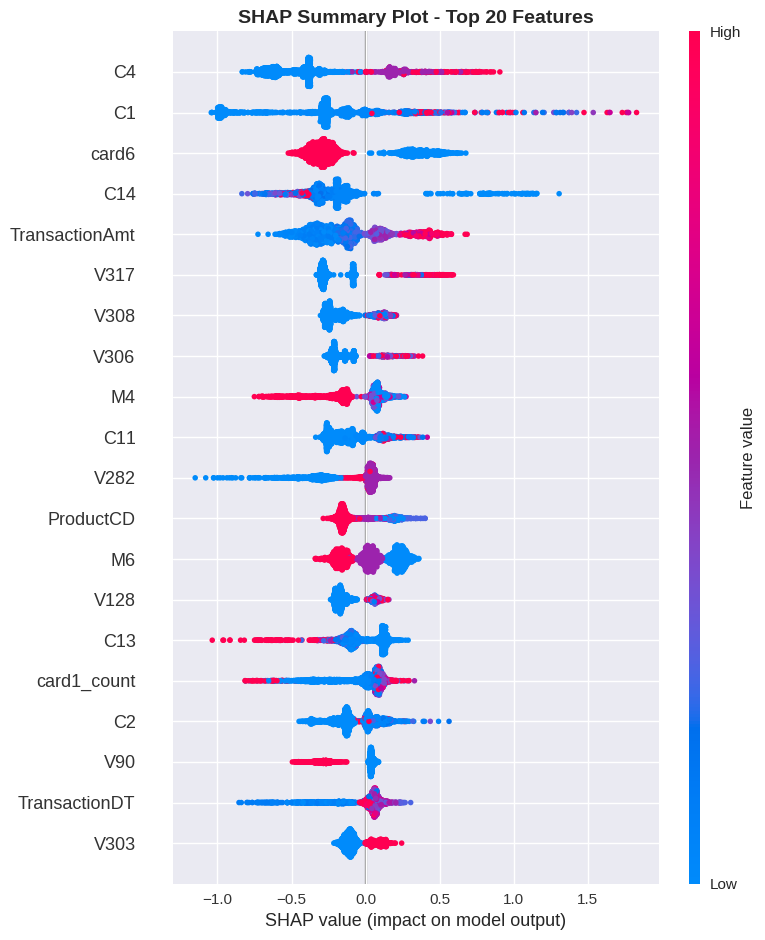

In [30]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot - Top 20 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.4 Feature Importance Bar Chart
A simpler view - average absolute SHAP value per feature.
This tells us the top features driving fraud predictions overall.

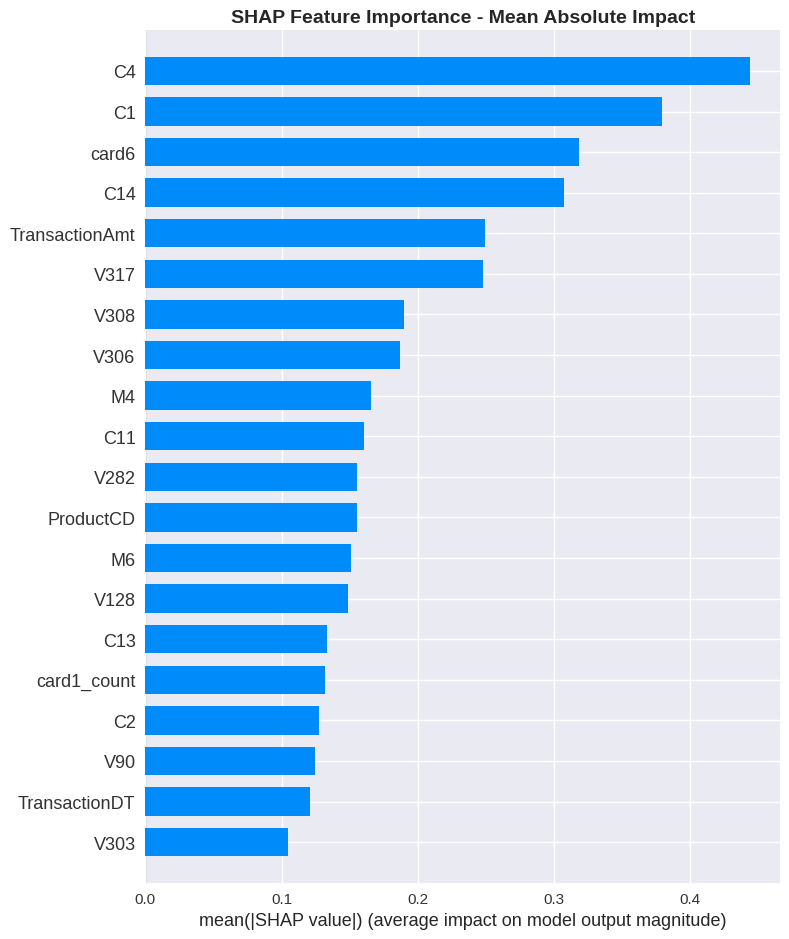

In [31]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance - Mean Absolute Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.5 Individual Transaction Explanation - Waterfall Plot
Now we explain a **single flagged transaction** in plain English.
The waterfall plot shows exactly which features pushed the score up or down
and by how much for that one specific transaction.

Explaining fraud transaction at position: 58


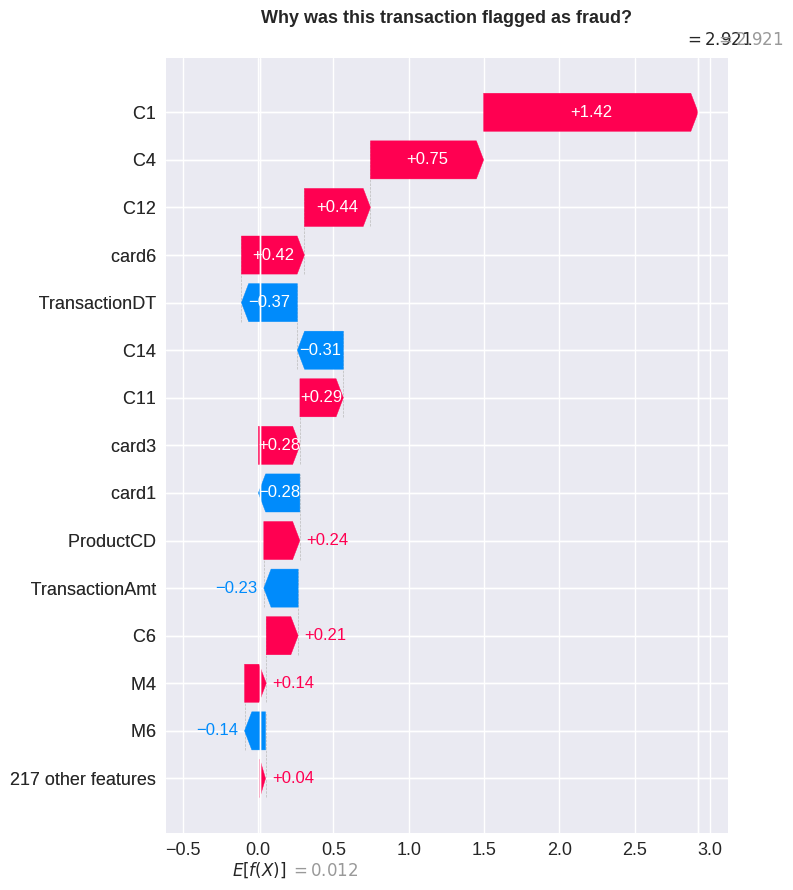

In [32]:
# Find a fraud transaction in our sample
fraud_indices = y_test_sample[y_test_sample == 1].index
first_fraud_pos = X_test_sample.index.get_loc(fraud_indices[0])

print(f"Explaining fraud transaction at position: {first_fraud_pos}")

# Waterfall plot for single transaction
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[first_fraud_pos],
    X_test_sample.iloc[first_fraud_pos],
    max_display=15,
    show=False
)
plt.title('Why was this transaction flagged as fraud?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.6 Plain English Explanation Generator
This function takes any transaction and generates a human-readable explanation
of why the model flagged it - suitable for fraud analysts and investigators.

In [57]:
def explain_transaction(index, X_sample, shap_vals, model, threshold=0.5):
    transaction = X_sample.iloc[index]
    prob = model.predict_proba(X_sample.iloc[[index]])[0][1]
    prediction = "FRAUD" if prob >= threshold else "LEGITIMATE"

    # Get top contributing features
    feature_shap = pd.Series(shap_vals[index], index=X_sample.columns)
    top_fraud_reasons    = feature_shap.nlargest(5)
    top_legit_reasons    = feature_shap.nsmallest(5)

    print(f"  Transaction Explanation Report")
    print(f"  Prediction     : {prediction}")
    print(f"  Fraud Score    : {prob:.4f} ({prob*100:.1f}% probability of fraud)")

    print("\nTop reasons this looks like FRAUD:")
    for feat, val in top_fraud_reasons.items():
        actual_val = transaction[feat]
        print(f"   - {feat}: {actual_val:.3f}  (impact: +{val:.4f})")

    print("\nTop reasons this looks LEGITIMATE:")
    for feat, val in top_legit_reasons.items():
        actual_val = transaction[feat]
        print(f"   - {feat}: {actual_val:.3f}  (impact: {val:.4f})")
    return prob

# Explain the first fraud transaction
print("Explaining first fraud transaction in test sample:\n")
explain_transaction(first_fraud_pos, X_test_sample, shap_values, xgb_model)

Explaining first fraud transaction in test sample:

  Transaction Explanation Report
  Prediction     : FRAUD
  Fraud Score    : 0.9489 (94.9% probability of fraud)

Top reasons this looks like FRAUD:
   - C1: 14.000  (impact: +1.4239)
   - C4: 10.000  (impact: +0.7514)
   - C12: 20.000  (impact: +0.4384)
   - card6: 1.000  (impact: +0.4183)
   - C11: 20.000  (impact: +0.2883)

Top reasons this looks LEGITIMATE:
   - TransactionDT: 1621689.000  (impact: -0.3714)
   - C14: 4.000  (impact: -0.3053)
   - card1: 16746.000  (impact: -0.2754)
   - TransactionAmt: 11.427  (impact: -0.2279)
   - M6: 2.000  (impact: -0.1394)


np.float32(0.94887704)

### 10.7 Explain Multiple Flagged Transactions
Let's run the explainer on the top 5 fraud transactions in our sample.

In [58]:
print("Top 5 Fraud Transaction Explanations\n")

fraud_positions = [
    X_test_sample.index.get_loc(idx)
    for idx in fraud_indices[:5]
]

for i, pos in enumerate(fraud_positions):
    print(f"\nFraud Transaction #{i+1}")
    explain_transaction(pos, X_test_sample, shap_values, xgb_model)

Top 5 Fraud Transaction Explanations


Fraud Transaction #1
  Transaction Explanation Report
  Prediction     : FRAUD
  Fraud Score    : 0.9489 (94.9% probability of fraud)

Top reasons this looks like FRAUD:
   - C1: 14.000  (impact: +1.4239)
   - C4: 10.000  (impact: +0.7514)
   - C12: 20.000  (impact: +0.4384)
   - card6: 1.000  (impact: +0.4183)
   - C11: 20.000  (impact: +0.2883)

Top reasons this looks LEGITIMATE:
   - TransactionDT: 1621689.000  (impact: -0.3714)
   - C14: 4.000  (impact: -0.3053)
   - card1: 16746.000  (impact: -0.2754)
   - TransactionAmt: 11.427  (impact: -0.2279)
   - M6: 2.000  (impact: -0.1394)

Fraud Transaction #2
  Transaction Explanation Report
  Prediction     : FRAUD
  Fraud Score    : 0.9797 (98.0% probability of fraud)

Top reasons this looks like FRAUD:
   - C1: 11.000  (impact: +1.2889)
   - C4: 6.000  (impact: +0.6519)
   - C11: 6.000  (impact: +0.3862)
   - C13: 1.000  (impact: +0.2490)
   - V62: 3.000  (impact: +0.2355)

Top reasons this looks

### 10.8 SHAP Dependence Plot
Shows how a single feature affects fraud predictions across all transactions.
We look at `TransactionAmt_log` - how does transaction amount relate to fraud risk?

<Figure size 1000x600 with 0 Axes>

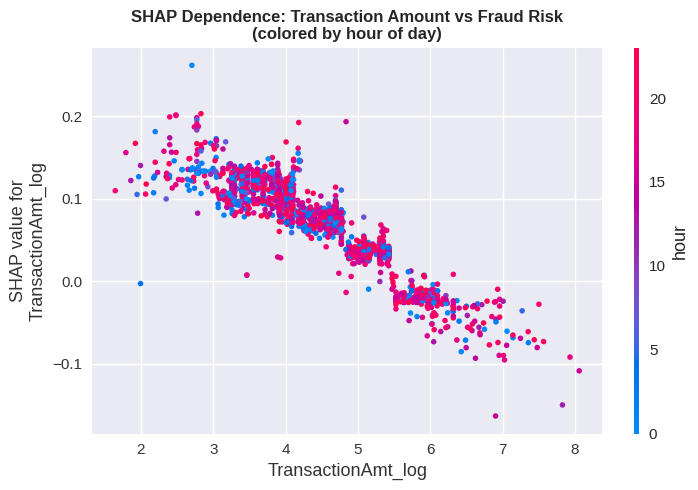

In [59]:
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    'TransactionAmt_log',
    shap_values,
    X_test_sample,
    interaction_index='hour',
    show=False
)
plt.title('SHAP Dependence: Transaction Amount vs Fraud Risk\n(colored by hour of day)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 11: Real-Time Scoring Simulation
In production, fraud models do not run on batches - they score every transaction
the moment it arrives, in milliseconds.

We simulate this by:
1. Building a scoring pipeline that accepts a raw transaction
2. Preprocessing it on the fly
3. Running it through XGBoost
4. Returning a fraud score, decision, and plain-English explanation
5. Measuring response time to confirm it meets production standards

### 11.1 Build the Real-Time Scoring Pipeline
This function mimics exactly what a production fraud API endpoint would do.

In [60]:
import time

def score_transaction(raw_transaction, model, explainer, feature_cols, threshold=0.5):
    """
    Scores a single transaction in real time.

    Parameters:
        raw_transaction : dict - raw transaction data
        model           : trained XGBoost model
        explainer       : SHAP TreeExplainer
        feature_cols    : list of feature names model expects
        threshold       : fraud decision threshold (default 0.5)

    Returns:
        result dict with score, decision, explanation, and latency
    """
    start_time = time.time()

    # Step 1 - Convert to DataFrame
    txn_df = pd.DataFrame([raw_transaction])

    # Step 2 - Align columns with training features
    for col in feature_cols:
        if col not in txn_df.columns:
            txn_df[col] = 0  # fill missing with 0

    txn_df = txn_df[feature_cols]

    # Step 3 - Fill any NaN
    txn_df = txn_df.fillna(0)

    # Step 4 - Score with model
    fraud_prob  = model.predict_proba(txn_df)[0][1]
    decision    = "FRAUD" if fraud_prob >= threshold else "LEGITIMATE"

    # Step 5 - SHAP explanation
    shap_vals   = explainer.shap_values(txn_df)
    feature_shap = pd.Series(shap_vals[0], index=feature_cols)
    top_reasons = feature_shap.nlargest(5)

    # Step 6 - Calculate latency
    latency_ms = (time.time() - start_time) * 1000

    result = {
        'fraud_probability' : round(float(fraud_prob), 4),
        'decision'          : decision,
        'risk_level'        : 'HIGH' if fraud_prob > 0.7 else 'MEDIUM' if fraud_prob > 0.4 else 'LOW',
        'top_reasons'       : top_reasons.to_dict(),
        'latency_ms'        : round(latency_ms, 2)
    }

    return result

print("Real-time scoring pipeline defined")

Real-time scoring pipeline defined


### 11.2 Score a Legitimate Transaction
We take a real transaction from our test set that was legitimate
and run it through the scoring pipeline.

In [61]:
# Pick a legitimate transaction from test set
legit_idx = y_test[y_test == 0].index[0]
legit_txn  = X_test.loc[legit_idx].to_dict()

result_legit = score_transaction(
    legit_txn, xgb_model, explainer,
    feature_cols=X_test.columns.tolist()
)

print("REAL-TIME SCORING RESULT - LEGITIMATE")
print(f"  Decision         : {result_legit['decision']}")
print(f"  Fraud Probability: {result_legit['fraud_probability']*100:.2f}%")
print(f"  Risk Level       : {result_legit['risk_level']}")
print(f"  Response Time    : {result_legit['latency_ms']} ms")
print("\n  Top Contributing Features:")
for feat, val in result_legit['top_reasons'].items():
    print(f"    - {feat}: {val:+.4f}")

REAL-TIME SCORING RESULT - LEGITIMATE
  Decision         : LEGITIMATE
  Fraud Probability: 1.47%
  Risk Level       : LOW
  Response Time    : 30.84 ms

  Top Contributing Features:
    - card6: +0.3007
    - M3: +0.1677
    - card1_count: +0.1337
    - V280: +0.0956
    - TransactionAmt_log: +0.0907


### 11.3 Score a Fraudulent Transaction
Now we run a known fraud transaction through the same pipeline.

In [62]:
# Pick a fraud transaction from test set
fraud_idx = y_test[y_test == 1].index[0]
fraud_txn  = X_test.loc[fraud_idx].to_dict()

result_fraud = score_transaction(
    fraud_txn, xgb_model, explainer,
    feature_cols=X_test.columns.tolist()
)

print("REAL-TIME SCORING RESULT - FRAUD")
print(f"  Decision         : {result_fraud['decision']}")
print(f"  Fraud Probability: {result_fraud['fraud_probability']*100:.2f}%")
print(f"  Risk Level       : {result_fraud['risk_level']}")
print(f"  Response Time    : {result_fraud['latency_ms']} ms")
print("\n  Top Contributing Features:")
for feat, val in result_fraud['top_reasons'].items():
    print(f"    - {feat}: {val:+.4f}")

REAL-TIME SCORING RESULT - FRAUD
  Decision         : FRAUD
  Fraud Probability: 94.89%
  Risk Level       : HIGH
  Response Time    : 38.65 ms

  Top Contributing Features:
    - C1: +1.4239
    - C4: +0.7514
    - C12: +0.4384
    - card6: +0.4183
    - C11: +0.2883


### 11.4 Batch Real-Time Simulation - Transaction Stream
We simulate a stream of 100 incoming transactions arriving one by one.
This is what a production system processes continuously 24/7.

In [63]:
# Simulate stream of 100 transactions
stream_size  = 100
stream_sample = X_test.iloc[:stream_size]
stream_labels = y_test.iloc[:stream_size]

results_list = []
latencies    = []

print(f"Simulating stream of {stream_size} transactions...\n")

for i in range(stream_size):
    txn = stream_sample.iloc[i].to_dict()
    res = score_transaction(
        txn, xgb_model, explainer,
        feature_cols=X_test.columns.tolist()
    )
    res['actual'] = 'FRAUD' if stream_labels.iloc[i] == 1 else 'LEGITIMATE'
    res['correct'] = res['decision'] == res['actual']
    results_list.append(res)
    latencies.append(res['latency_ms'])

results_stream = pd.DataFrame(results_list)

print(f"Stream simulation complete")
print(f"\nStream Summary:")
print(f"   Total transactions  : {stream_size}")
print(f"   Fraud flagged       : {(results_stream['decision']=='FRAUD').sum()}")
print(f"   Correct decisions   : {results_stream['correct'].sum()}")
print(f"   Accuracy            : {results_stream['correct'].mean()*100:.1f}%")
print(f"\nLatency Stats:")
print(f"   Average : {pd.Series(latencies).mean():.2f} ms")
print(f"   Min     : {pd.Series(latencies).min():.2f} ms")
print(f"   Max     : {pd.Series(latencies).max():.2f} ms")
print(f"   P95     : {pd.Series(latencies).quantile(0.95):.2f} ms")

Simulating stream of 100 transactions...

Stream simulation complete

Stream Summary:
   Total transactions  : 100
   Fraud flagged       : 3
   Correct decisions   : 100
   Accuracy            : 100.0%

Latency Stats:
   Average : 51.73 ms
   Min     : 26.93 ms
   Max     : 271.79 ms
   P95     : 96.44 ms


### 11.5 Visualise Stream Results

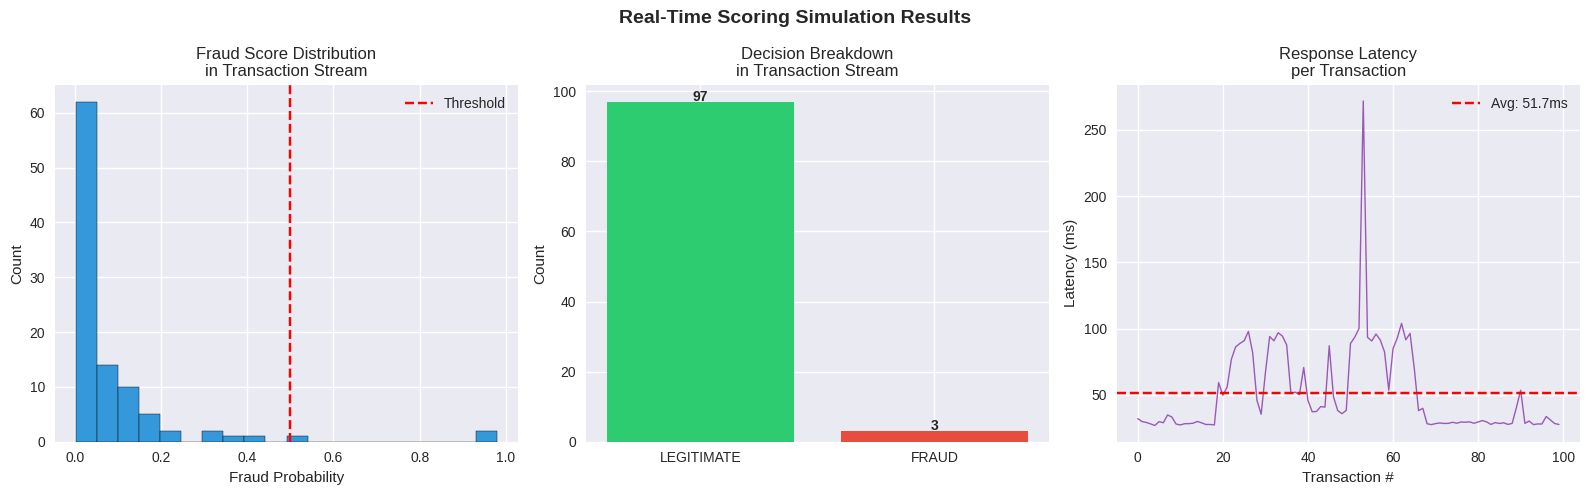

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Fraud probability distribution in stream
axes[0].hist(results_stream['fraud_probability'],
             bins=20, color='#3498db', edgecolor='black')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Threshold')
axes[0].set_title('Fraud Score Distribution\nin Transaction Stream')
axes[0].set_xlabel('Fraud Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# Decision breakdown
decision_counts = results_stream['decision'].value_counts()
axes[1].bar(decision_counts.index, decision_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Decision Breakdown\nin Transaction Stream')
axes[1].set_ylabel('Count')
for i, v in enumerate(decision_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Latency over time
axes[2].plot(latencies, color='#9b59b6', linewidth=1)
axes[2].axhline(y=pd.Series(latencies).mean(),
                color='red', linestyle='--',
                label=f"Avg: {pd.Series(latencies).mean():.1f}ms")
axes[2].set_title('Response Latency\nper Transaction')
axes[2].set_xlabel('Transaction #')
axes[2].set_ylabel('Latency (ms)')
axes[2].legend()

plt.suptitle('Real-Time Scoring Simulation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.6 Save the Model for Production Use
We save the trained XGBoost model so it can be loaded by the Streamlit dashboard
without retraining every time.

In [65]:
import pickle
import os

# Create models directory in Drive
model_dir = '/content/drive/MyDrive/Projects/fraud_detection/models'
os.makedirs(model_dir, exist_ok=True)

# Save XGBoost model
with open(f'{model_dir}/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save feature columns list
with open(f'{model_dir}/feature_cols.pkl', 'wb') as f:
    pickle.dump(X_test.columns.tolist(), f)

# Save a sample of test data for dashboard
X_test.iloc[:500].to_csv(f'{model_dir}/sample_transactions.csv', index=False)
y_test.iloc[:500].to_csv(f'{model_dir}/sample_labels.csv', index=False)

print("Model saved successfully")
print(f"Location: {model_dir}")
print("\nFiles saved:")
print("   - xgb_model.pkl")
print("   - feature_cols.pkl")
print("   - sample_transactions.csv")
print("   - sample_labels.csv")

Model saved successfully
Location: /content/drive/MyDrive/Projects/fraud_detection/models

Files saved:
   - xgb_model.pkl
   - feature_cols.pkl
   - sample_transactions.csv
   - sample_labels.csv


## Step 12: SQL Integration
In production, fraud detection systems sit on top of databases.
Every transaction is stored, every flag is logged, every investigation is tracked.

We simulate this production database pipeline using SQLite
(no server needed - works directly in Colab) with queries that would
work identically in MySQL or PostgreSQL in a real bank's infrastructure.

We will:
1. Create a transactions database
2. Insert scored transactions
3. Write production-grade SQL queries for fraud analysis
4. Simulate what a fraud analyst would query daily

### 12.1 Set Up SQLite Database

In [66]:
import sqlite3
import pandas as pd

# Create database
db_path = '/content/drive/MyDrive/Projects/fraud_detection/fraud_detection.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

print("Database connection established")
print(f"Database location: {db_path}")

Database connection established
Database location: /content/drive/MyDrive/Projects/fraud_detection/fraud_detection.db


### 12.2 Create Database Tables
We create three tables that mirror a real production fraud system:
- `transactions` - every incoming transaction with its fraud score
- `fraud_alerts` - only flagged transactions with investigation status
- `model_performance` - daily model metrics tracked over time

In [67]:
# Drop tables if they exist (clean start)
cursor.executescript("""
    DROP TABLE IF EXISTS transactions;
    DROP TABLE IF EXISTS fraud_alerts;
    DROP TABLE IF EXISTS model_performance;
""")

# Create transactions table
cursor.execute("""
    CREATE TABLE transactions (
        transaction_id      INTEGER PRIMARY KEY,
        transaction_amt     REAL,
        fraud_probability   REAL,
        risk_level          TEXT,
        decision            TEXT,
        actual_label        INTEGER,
        hour                INTEGER,
        day_of_week         INTEGER,
        card1_count         INTEGER,
        amt_deviation       REAL,
        is_round_amount     INTEGER,
        scored_at           TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
""")

# Create fraud alerts table
cursor.execute("""
    CREATE TABLE fraud_alerts (
        alert_id            INTEGER PRIMARY KEY AUTOINCREMENT,
        transaction_id      INTEGER,
        fraud_probability   REAL,
        risk_level          TEXT,
        top_reason          TEXT,
        investigation_status TEXT DEFAULT 'PENDING',
        analyst_notes       TEXT,
        created_at          TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        FOREIGN KEY (transaction_id) REFERENCES transactions(transaction_id)
    )
""")

# Create model performance table
cursor.execute("""
    CREATE TABLE model_performance (
        record_id       INTEGER PRIMARY KEY AUTOINCREMENT,
        model_name      TEXT,
        precision_score REAL,
        recall_score    REAL,
        f1_score        REAL,
        auc_roc         REAL,
        recorded_at     TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
""")

conn.commit()
print("All tables created successfully")
print("\nTables created:")
print("   - transactions")
print("   - fraud_alerts")
print("   - model_performance")

All tables created successfully

Tables created:
   - transactions
   - fraud_alerts
   - model_performance


### 12.3 Insert Scored Transactions into Database
We insert our 500 sample scored transactions into the database
exactly as a production pipeline would after scoring each transaction.

In [68]:
# Prepare data for insertion
insert_data = []

for i in range(len(results_stream)):
    row = results_stream.iloc[i]
    txn = stream_sample.iloc[i]

    insert_data.append((
        i + 1,
        float(txn.get('TransactionAmt', 0)),
        float(row['fraud_probability']),
        row['risk_level'],
        row['decision'],
        1 if row['actual'] == 'FRAUD' else 0,
        int(txn.get('hour', 0)),
        int(txn.get('day_of_week', 0)),
        int(txn.get('card1_count', 0)),
        float(txn.get('amt_deviation', 0)),
        int(txn.get('is_round_amount', 0))
    ))

cursor.executemany("""
    INSERT INTO transactions (
        transaction_id, transaction_amt, fraud_probability,
        risk_level, decision, actual_label,
        hour, day_of_week, card1_count,
        amt_deviation, is_round_amount
    ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
""", insert_data)

conn.commit()
print(f"{len(insert_data)} transactions inserted into database")

100 transactions inserted into database


### 12.4 Insert Fraud Alerts
For every transaction flagged as fraud we create an alert record
with the top reason and a PENDING investigation status.

In [69]:
fraud_rows = results_stream[results_stream['decision'] == 'FRAUD']

alert_data = []
for i, row in fraud_rows.iterrows():
    top_reason = list(row['top_reasons'].keys())[0] if row['top_reasons'] else 'Unknown'
    alert_data.append((
        i + 1,
        float(row['fraud_probability']),
        row['risk_level'],
        top_reason,
        'PENDING'
    ))

cursor.executemany("""
    INSERT INTO fraud_alerts (
        transaction_id, fraud_probability,
        risk_level, top_reason, investigation_status
    ) VALUES (?, ?, ?, ?, ?)
""", alert_data)

conn.commit()
print(f"{len(alert_data)} fraud alerts inserted")

3 fraud alerts inserted


### 12.5 Insert Model Performance Record
We log today's model metrics into the database.
This lets data science teams track model drift over time.

In [70]:
cursor.execute("""
    INSERT INTO model_performance (
        model_name, precision_score, recall_score, f1_score, auc_roc
    ) VALUES (?, ?, ?, ?, ?)
""", (
    'XGBoost',
    round(xgb_results['precision'], 4),
    round(xgb_results['recall'], 4),
    round(xgb_results['f1'], 4),
    round(xgb_results['auc'], 4)
))

conn.commit()
print("Model performance record inserted")

Model performance record inserted


### 12.6 Production SQL Queries
These are the exact queries a fraud analyst or data engineer would run
every day in a real banking fraud system.

In [71]:
print("  QUERY 1: Overall Fraud Summary")

q1 = pd.read_sql_query("""
    SELECT
        decision,
        COUNT(*)                        AS total_transactions,
        ROUND(AVG(fraud_probability)*100, 2)  AS avg_fraud_score_pct,
        ROUND(AVG(transaction_amt), 2)  AS avg_transaction_amt,
        ROUND(MIN(transaction_amt), 2)  AS min_amt,
        ROUND(MAX(transaction_amt), 2)  AS max_amt
    FROM transactions
    GROUP BY decision
""", conn)
print(q1.to_string(index=False))

  QUERY 1: Overall Fraud Summary
  decision  total_transactions  avg_fraud_score_pct  avg_transaction_amt  min_amt  max_amt
     FRAUD                   3                82.16               129.13    10.96   365.00
LEGITIMATE                  97                 6.55               137.78    13.71  2508.16


In [72]:
print("  QUERY 2: Fraud Rate by Risk Level")

q2 = pd.read_sql_query("""
    SELECT
        risk_level,
        COUNT(*)                              AS total,
        SUM(actual_label)                     AS actual_frauds,
        ROUND(AVG(fraud_probability)*100, 2)  AS avg_score_pct
    FROM transactions
    GROUP BY risk_level
    ORDER BY avg_score_pct DESC
""", conn)
print(q2.to_string(index=False))

  QUERY 2: Fraud Rate by Risk Level
risk_level  total  actual_frauds  avg_score_pct
      HIGH      2              2          96.43
    MEDIUM      2              1          46.88
       LOW     96              0           6.20


In [73]:
print("  QUERY 3: Fraud Rate by Hour of Day")

q3 = pd.read_sql_query("""
    SELECT
        hour,
        COUNT(*)                        AS total_transactions,
        SUM(actual_label)               AS fraud_count,
        ROUND(SUM(actual_label) * 100.0
              / COUNT(*), 2)            AS fraud_rate_pct
    FROM transactions
    GROUP BY hour
    ORDER BY fraud_rate_pct DESC
    LIMIT 10
""", conn)
print(q3.to_string(index=False))

  QUERY 3: Fraud Rate by Hour of Day
 hour  total_transactions  fraud_count  fraud_rate_pct
   18                   9            2           22.22
    2                   7            1           14.29
   23                   6            0            0.00
   22                   7            0            0.00
   21                   6            0            0.00
   20                   5            0            0.00
   19                  10            0            0.00
   17                   5            0            0.00
   16                   9            0            0.00
   15                   3            0            0.00


In [74]:
print("  QUERY 4: High Risk Pending Alerts")

q4 = pd.read_sql_query("""
    SELECT
        a.alert_id,
        a.transaction_id,
        ROUND(a.fraud_probability*100, 1) AS fraud_score_pct,
        a.risk_level,
        a.top_reason,
        a.investigation_status,
        t.transaction_amt
    FROM fraud_alerts a
    JOIN transactions t ON a.transaction_id = t.transaction_id
    WHERE a.investigation_status = 'PENDING'
    AND a.risk_level = 'HIGH'
    ORDER BY a.fraud_probability DESC
    LIMIT 10
""", conn)
print(q4.to_string(index=False))

  QUERY 4: High Risk Pending Alerts
 alert_id  transaction_id  fraud_score_pct risk_level top_reason investigation_status  transaction_amt
        2              63             98.0       HIGH         C1              PENDING           10.960
        1              59             94.9       HIGH         C1              PENDING           11.427


In [75]:
print("  QUERY 5: Model Performance Log")

q5 = pd.read_sql_query("""
    SELECT
        model_name,
        ROUND(precision_score, 4)  AS precision,
        ROUND(recall_score, 4)     AS recall,
        ROUND(f1_score, 4)         AS f1,
        ROUND(auc_roc, 4)          AS auc_roc,
        recorded_at
    FROM model_performance
    ORDER BY recorded_at DESC
""", conn)
print(q5.to_string(index=False))

# Close connection
conn.close()
print("\nDatabase connection closed")
print("SQL integration complete")

  QUERY 5: Model Performance Log
model_name  precision  recall     f1  auc_roc         recorded_at
   XGBoost     0.6359  0.5519 0.5909   0.9226 2026-06-11 20:31:26

Database connection closed
SQL integration complete


### 12.7 Summary - What This SQL Layer Does in Production
| Query | Purpose |
|-------|---------|
| Overall Fraud Summary | Daily executive dashboard |
| Fraud by Risk Level | Triage and prioritisation |
| Fraud by Hour | Pattern detection for rules engine |
| High Risk Pending Alerts | Analyst investigation queue |
| Model Performance Log | Model monitoring and drift detection |

In a real bank this database would be MySQL or PostgreSQL,
queries would run on scheduled jobs every hour,
and alerts would trigger automatic case creation in investigation tools.

## Step 13: Streamlit Fraud Analyst Dashboard
The final piece - a full interactive dashboard for fraud analysts.

Features:
- Live transaction scoring
- Flagged transactions queue with risk levels
- SHAP explanation for every flagged transaction
- Investigation workflow (mark as confirmed fraud / false positive)
- Model performance metrics panel

### 13.1 Install Streamlit and Tunnel

In [76]:
!pip install streamlit -q

print("Streamlit installed")

Streamlit installed


### 13.2 Export All Files for Deployment
We export the trained model, feature columns, sample data, and model results
into a dedicated deployment folder that will be uploaded to Hugging Face.

In [77]:
import pickle
import os
import json

# Create deployment folder
export_path = '/content/drive/MyDrive/Projects/fraud_detection/hf_deploy'
os.makedirs(export_path, exist_ok=True)

# Save XGBoost model
with open(f'{export_path}/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save feature columns
with open(f'{export_path}/feature_cols.pkl', 'wb') as f:
    pickle.dump(X_test.columns.tolist(), f)

# Save sample data
X_test.iloc[:500].to_csv(f'{export_path}/sample_transactions.csv', index=False)
y_test.iloc[:500].to_csv(f'{export_path}/sample_labels.csv', index=False)

# Save model results - skip the 'model' key since it is a string not a number
def clean_results(d):
    cleaned = {}
    for k, v in d.items():
        if k == 'model':
            cleaned[k] = v  # keep as string
        elif v is None:
            cleaned[k] = None
        else:
            cleaned[k] = float(v)
    return cleaned

model_results = {
    'xgb': clean_results(xgb_results),
    'rf':  clean_results(rf_results),
    'iso': clean_results(iso_results)
}

with open(f'{export_path}/model_results.json', 'w') as f:
    json.dump(model_results, f)

print("All files exported to hf_deploy folder")
print("\nFiles ready:")
for f in os.listdir(export_path):
    size = os.path.getsize(f'{export_path}/{f}') / (1024*1024)
    print(f"   - {f}  ({size:.1f} MB)")

All files exported to hf_deploy folder

Files ready:
   - xgb_model.pkl  (1.1 MB)
   - feature_cols.pkl  (0.0 MB)
   - sample_transactions.csv  (0.5 MB)
   - sample_labels.csv  (0.0 MB)
   - model_results.json  (0.0 MB)
   - app.py  (0.0 MB)
   - requirements.txt  (0.0 MB)


### 13.3 Check Model File Size
We verify the model size before uploading to Hugging Face.
Anything under 100MB uploads directly via the browser.
Over 100MB requires Git LFS - we handle that separately.

In [78]:
model_path = '/content/drive/MyDrive/Projects/fraud_detection/hf_deploy/xgb_model.pkl'
size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Model size: {size_mb:.1f} MB")

if size_mb > 100:
    print("Model is large - use Git LFS to upload to Hugging Face")
else:
    print("Model size is fine - upload directly via Hugging Face browser UI")

Model size: 1.1 MB
Model size is fine - upload directly via Hugging Face browser UI


### 13.4 Write the Streamlit App for Hugging Face
This version loads all files locally instead of from Google Drive
so it works correctly when deployed on Hugging Face Spaces.

In [79]:
hf_app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
import json
import os

# Page Config
st.set_page_config(
    page_title="Fraud Detection System",
    page_icon="🏦",
    layout="wide"
)

# Load Model and Data
@st.cache_resource
def load_model():
    with open("xgb_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("feature_cols.pkl", "rb") as f:
        feature_cols = pickle.load(f)
    return model, feature_cols

@st.cache_data
def load_data():
    X = pd.read_csv("sample_transactions.csv")
    y = pd.read_csv("sample_labels.csv")
    with open("model_results.json", "r") as f:
        results = json.load(f)
    return X, y, results

model, feature_cols          = load_model()
X_sample, y_sample, model_results = load_data()

# Compute scores
probs       = model.predict_proba(X_sample[feature_cols])[:, 1]
decisions   = ["FRAUD" if p >= 0.5 else "LEGITIMATE" for p in probs]
risk_levels = ["HIGH" if p > 0.7 else "MEDIUM" if p > 0.4 else "LOW" for p in probs]

results_df = X_sample.copy()
results_df["fraud_probability"] = probs
results_df["decision"]          = decisions
results_df["risk_level"]        = risk_levels
results_df["actual"]            = y_sample.values.flatten()

xgb_results = model_results["xgb"]
rf_results  = model_results["rf"]
iso_results = model_results["iso"]

# Sidebar
st.sidebar.title("Fraud Detection")
st.sidebar.markdown("---")
page = st.sidebar.radio(
    "Navigate",
    ["Overview", "Fraud Alerts", "Transaction Scorer", "Model Performance"]
)
st.sidebar.markdown("---")
st.sidebar.markdown(f"**Total Transactions:** {len(results_df):,}")
st.sidebar.markdown(f"**Fraud Flagged:** {(results_df[\'decision\']==\'FRAUD\').sum():,}")
st.sidebar.markdown(f"**Fraud Rate:** {results_df[\'actual\'].mean()*100:.2f}%")

# PAGE 1 - OVERVIEW
if page == "Overview":
    st.title("Fraud Detection - Overview Dashboard")
    st.markdown("---")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Transactions", f"{len(results_df):,}")
    col2.metric("Fraud Flagged",      f"{(results_df[\'decision\']==\'FRAUD\').sum():,}")
    col3.metric("High Risk Alerts",   f"{(results_df[\'risk_level\']==\'HIGH\').sum():,}")
    col4.metric("Avg Fraud Score",    f"{results_df[\'fraud_probability\'].mean()*100:.1f}%")

    st.markdown("---")
    col_a, col_b = st.columns(2)

    with col_a:
        st.subheader("Fraud Score Distribution")
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(results_df[results_df["actual"]==0]["fraud_probability"],
                bins=30, alpha=0.7, color="#2ecc71", label="Legitimate")
        ax.hist(results_df[results_df["actual"]==1]["fraud_probability"],
                bins=30, alpha=0.7, color="#e74c3c", label="Fraud")
        ax.axvline(x=0.5, color="black", linestyle="--", label="Threshold")
        ax.set_xlabel("Fraud Probability")
        ax.set_ylabel("Count")
        ax.legend()
        st.pyplot(fig)
        plt.close()

    with col_b:
        st.subheader("Risk Level Breakdown")
        risk_counts = results_df["risk_level"].value_counts()
        colors = {"HIGH": "#e74c3c", "MEDIUM": "#f39c12", "LOW": "#2ecc71"}
        fig2, ax2 = plt.subplots(figsize=(6, 4))
        ax2.bar(risk_counts.index, risk_counts.values,
                color=[colors.get(r, "#3498db") for r in risk_counts.index])
        ax2.set_ylabel("Count")
        for i, v in enumerate(risk_counts.values):
            ax2.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
        st.pyplot(fig2)
        plt.close()

    st.markdown("---")
    st.subheader("Fraud Rate by Hour of Day")
    if "hour" in results_df.columns:
        hour_fraud = results_df.groupby(results_df["hour"].astype(int))["actual"].mean() * 100
        fig3, ax3  = plt.subplots(figsize=(12, 4))
        ax3.bar(hour_fraud.index, hour_fraud.values, color="#3498db")
        ax3.set_xlabel("Hour of Day")
        ax3.set_ylabel("Fraud Rate %")
        st.pyplot(fig3)
        plt.close()

# PAGE 2 - FRAUD ALERTS
elif page == "Fraud Alerts":
    st.title("Fraud Alerts - Investigation Queue")
    st.markdown("---")

    fraud_df = results_df[results_df["decision"] == "FRAUD"].copy()
    fraud_df = fraud_df.sort_values("fraud_probability", ascending=False)
    fraud_df["fraud_score_%"] = (fraud_df["fraud_probability"] * 100).round(1)

    col1, col2 = st.columns(2)
    risk_filter     = col1.multiselect("Filter by Risk Level",
                                        ["HIGH", "MEDIUM", "LOW"],
                                        default=["HIGH", "MEDIUM"])
    score_threshold = col2.slider("Minimum Fraud Score %", 50, 100, 50)

    filtered = fraud_df[
        (fraud_df["risk_level"].isin(risk_filter)) &
        (fraud_df["fraud_score_%"] >= score_threshold)
    ]

    st.markdown(f"**Showing {len(filtered)} alerts**")
    display_cols = ["fraud_score_%", "risk_level", "TransactionAmt",
                    "hour", "amt_deviation", "is_round_amount"]
    display_cols = [c for c in display_cols if c in filtered.columns]
    st.dataframe(filtered[display_cols].reset_index(drop=True),
                 use_container_width=True, height=400)

    st.markdown("---")
    st.subheader("Investigate a Specific Alert")
    alert_idx = st.number_input("Enter row number to investigate",
                                 min_value=0,
                                 max_value=max(len(filtered)-1, 0),
                                 value=0)

    if st.button("Run SHAP Explanation"):
        selected  = filtered.iloc[int(alert_idx)]
        with st.spinner("Computing SHAP explanation..."):
            explainer_dash = shap.TreeExplainer(model)
            txn_df    = pd.DataFrame([selected[feature_cols]])
            shap_vals = explainer_dash.shap_values(txn_df)
            feat_shap = pd.Series(shap_vals[0], index=feature_cols)
            top_fraud = feat_shap.nlargest(5)
            top_legit = feat_shap.nsmallest(5)

            col_x, col_y = st.columns(2)
            with col_x:
                st.markdown("**Top reasons flagged as FRAUD:**")
                for feat, val in top_fraud.items():
                    st.markdown(f"- `{feat}`: impact `{val:+.4f}`")
            with col_y:
                st.markdown("**Top reasons against fraud:**")
                for feat, val in top_legit.items():
                    st.markdown(f"- `{feat}`: impact `{val:+.4f}`")

    st.markdown("---")
    col_p, col_q = st.columns(2)
    if col_p.button("Mark as False Positive"):
        st.success("Marked as False Positive - removed from queue")
    if col_q.button("Confirm as Fraud"):
        st.error("Confirmed as Fraud - case escalated to investigation team")

# PAGE 3 - TRANSACTION SCORER
elif page == "Transaction Scorer":
    st.title("Real-Time Transaction Scorer")
    st.markdown("Score any transaction instantly using the live model.")
    st.markdown("---")

    col1, col2, col3 = st.columns(3)
    amt       = col1.number_input("Transaction Amount ($)", min_value=0.0, value=150.0)
    hour_val  = col2.slider("Hour of Day", 0, 23, 14)
    day_val   = col3.slider("Day of Week", 0, 6, 3)

    col4, col5 = st.columns(2)
    card_count = col4.number_input("Card Transaction Count", min_value=1, value=10)
    amt_dev    = col5.number_input("Amount Deviation", value=0.5)
    round_amt  = st.checkbox("Is Round Amount?")

    if st.button("⚡ Score Transaction Now"):
        raw = {col: 0 for col in feature_cols}
        raw.update({
            "TransactionAmt":         amt,
            "TransactionAmt_log":     np.log1p(amt),
            "TransactionAmt_decimal": amt - int(amt),
            "is_round_amount":        int(round_amt),
            "hour":                   hour_val,
            "day_of_week":            day_val,
            "card1_count":            card_count,
            "amt_deviation":          amt_dev,
        })
        txn_df = pd.DataFrame([raw])[feature_cols]
        prob   = model.predict_proba(txn_df)[0][1]
        risk   = "HIGH" if prob > 0.7 else "MEDIUM" if prob > 0.4 else "LOW"
        dec    = "FRAUD" if prob >= 0.5 else "LEGITIMATE"

        st.markdown("---")
        r1, r2, r3 = st.columns(3)
        r1.metric("Decision",    dec)
        r2.metric("Fraud Score", f"{prob*100:.1f}%")
        r3.metric("Risk Level",  risk)
        st.progress(float(prob))

# PAGE 4 - MODEL PERFORMANCE
elif page == "Model Performance":
    st.title("Model Performance Metrics")
    st.markdown("---")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("XGBoost Precision", f"{xgb_results[\'precision\']:.4f}")
    col2.metric("XGBoost Recall",    f"{xgb_results[\'recall\']:.4f}")
    col3.metric("XGBoost F1",        f"{xgb_results[\'f1\']:.4f}")
    col4.metric("XGBoost AUC-ROC",   f"{xgb_results[\'auc\']:.4f}")

    st.markdown("---")
    st.subheader("Model Comparison")
    compare_df = pd.DataFrame([xgb_results, rf_results, iso_results])
    compare_df = compare_df.set_index("model").round(4)
    st.dataframe(compare_df, use_container_width=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    compare_df[["precision", "recall", "f1"]].plot(
        kind="bar", ax=ax,
        color=["#3498db", "#e74c3c", "#2ecc71"],
        edgecolor="black"
    )
    ax.set_title("Model Comparison - Precision, Recall, F1")
    ax.set_ylabel("Score")
    plt.xticks(rotation=0)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close()
'''

hf_app_path = '/content/drive/MyDrive/Projects/fraud_detection/hf_deploy/app.py'
with open(hf_app_path, 'w') as f:
    f.write(hf_app_code)

print("Hugging Face app.py written successfully")
print(f"Saved to: {hf_app_path}")

Hugging Face app.py written successfully
Saved to: /content/drive/MyDrive/Projects/fraud_detection/hf_deploy/app.py


### 13.5 Write Requirements File
Hugging Face needs this file to know which libraries to install
when it builds your Space.

In [80]:
requirements = """streamlit
pandas
numpy
matplotlib
scikit-learn
xgboost
shap
"""

req_path = '/content/drive/MyDrive/Projects/fraud_detection/hf_deploy/requirements.txt'
with open(req_path, 'w') as f:
    f.write(requirements)

print("requirements.txt written")
print("\nAll files ready for Hugging Face upload:")
for file in os.listdir('/content/drive/MyDrive/Projects/fraud_detection/hf_deploy'):
    size = os.path.getsize(
        f'/content/drive/MyDrive/Projects/fraud_detection/hf_deploy/{file}'
    ) / (1024*1024)
    print(f"   - {file}  ({size:.1f} MB)")

requirements.txt written

All files ready for Hugging Face upload:
   - xgb_model.pkl  (1.1 MB)
   - feature_cols.pkl  (0.0 MB)
   - sample_transactions.csv  (0.5 MB)
   - sample_labels.csv  (0.0 MB)
   - model_results.json  (0.0 MB)
   - app.py  (0.0 MB)
   - requirements.txt  (0.0 MB)
